In [2]:
import os
os.environ["TORCH_CPP_LOG_LEVEL"] = "ERROR"

from input_process import FrameClipDataset, extract_frames
from event_detection import EventDetectionModel, load_event_detection_model
from ball_tracking import BallTrackingModel
from table_detector import TableDetector
from utils.visualization import draw_bounces_on_split_table, draw_bounces_on_table
from analysis import AnalysisUtils
import torch
import torchvision.transforms as transforms
import json
import argparse
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image


CLASS_CONVERSION = {
    0: 'empty',
    1: 'far_table_bounce',
    2: 'far_table_forehand',
    3: 'far_table_backhand',
    4: 'far_table_serve',
    5: 'close_table_bounce',
    6: 'close_table_forehand',
    7: 'close_table_backhand',
    8: 'close_table_serve',
}


/scratch/mn65/miniconda3/envs/TTA/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'attrdict'

In [ ]:
# convert them to variable 
window_size = 100
stride = 50
video_path = '/data/25WPF_TPE_W4-5_G_Di_Toro_AUS_v_Lin_Yen_Ying_TPE_game1.mp4'
device = 'cuda' # or cpu or mps for mac


In [5]:
event_transform = transforms.Compose([
        transforms.CenterCrop(size=(224, 224)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
ball_transform = transforms.Compose([
    transforms.Resize((288, 512)),
    # transforms.CenterCrop(size=(224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
frame_dir, fps_rate = extract_frames(video_path, resize_to=(398, 224))
game_name = os.path.basename(video_path).split('.')[0]
print(f'Extracted frames for {game_name} into {frame_dir}')

dataset = FrameClipDataset(frame_dir, window_size=window_size, stride=stride, event_transform=event_transform, ball_transform=ball_transform)
video_loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False, num_workers=4)
print(f'Video Loader initialized with {len(dataset)} clips')

# Load event detection model configuration
event_model_config = 'event_detection/model_configs/e2e_res18_hagsm.json'
with open(event_model_config, 'r') as f:
    event_model_config = json.load(f)

# Initialize event detection model
event_model = EventDetectionModel(event_model_config, device=device)
load_event_detection_model(event_model, 'event_detection/checkpoints/E2E_RES18_HAGSM_TTA.pt')


print(f'Event Detection Model initialized successfully')

# Initialize ball tracking model
ball_tracking_model = BallTrackingModel(
    model_choice='TOTNet',
    model_args=type('', (), {'img_size': (288, 512), 'num_frames': 5, 'device': device})(),
    checkpoint_path='ball_tracking/checkpoints/TOTNet_TTA_(5)_(288,512)_30epochs_best.pth'
)
TOTNet_OF = BallTrackingModel(
    model_choice='TOTNet_OF',
    model_args=type('', (), {'img_size': (288, 512), 'num_frames': 5, 'device': device})(),
    checkpoint_path='ball_tracking/checkpoints/TOTNet_OF_TTA_(5)_(288,512)_30epochs_best.pth'
)

print(f'Ball Tracking Model initialized successfully')

# Generate predictions
pred_events = {}
threshold = 0.05  # threshold for event detection scores, can be adjusted

Frame directory /home/august/github/TTA_Project/data/25WPF_TPE_W4-5_G_Di_Toro_AUS_v_Lin_Yen_Ying_TPE_game1_frames already exists, skipping extraction, fps: 30.0
Extracted frames for 25WPF_TPE_W4-5_G_Di_Toro_AUS_v_Lin_Yen_Ying_TPE_game1 into /home/august/github/TTA_Project/data/25WPF_TPE_W4-5_G_Di_Toro_AUS_v_Lin_Yen_Ying_TPE_game1_frames
Video Loader initialized with 167 clips
=> Processing stage with 2 blocks residual
=> Using HAGSM, fold dim: 16 / 64, [1, 2, 3], number of heads 2
=> Using HAGSM, fold dim: 16 / 64, [1, 2, 3], number of heads 2
=> Processing stage with 2 blocks residual
=> Using HAGSM, fold dim: 16 / 64, [1, 2, 3], number of heads 2
=> Using HAGSM, fold dim: 32 / 128, [1, 2, 3], number of heads 2
=> Processing stage with 2 blocks residual
=> Using HAGSM, fold dim: 32 / 128, [1, 2, 3], number of heads 2
=> Using HAGSM, fold dim: 64 / 256, [1, 2, 3], number of heads 2
=> Processing stage with 2 blocks residual
=> Using HAGSM, fold dim: 64 / 256, [1, 2, 3], number of heads

✅ Loaded 242/242 params
Missing keys:

Unexpected keys in checkpoint:

Event Detection Model initialized successfully
=> Loading pretrained weights from 'ball_tracking/checkpoints/TOTNet_TTA_(5)_(288,512)_30epochs_best.pth'
=> Loaded pretrained weights successfully from 'ball_tracking/checkpoints/TOTNet_TTA_(5)_(288,512)_30epochs_best.pth'
=> 196 layers loaded. 0 unmatched.
=> Loading pretrained weights from 'ball_tracking/checkpoints/TOTNet_OF_TTA_(5)_(288,512)_30epochs_best.pth'
=> Loaded pretrained weights successfully from 'ball_tracking/checkpoints/TOTNet_OF_TTA_(5)_(288,512)_30epochs_best.pth'
=> 370 layers loaded. 0 unmatched.
Ball Tracking Model initialized successfully


In [6]:
# generating event predictions
for data in tqdm(video_loader, desc="Processing clips"):
    clips = data['frames']
    start_idx = data['start_idx']
    end_idx = data['end_idx']
    clips = clips.to(device, dtype=torch.float32)
    # Process clips with event detection model
    pred_results, pred_scores = event_model.predict(clips)

    # print(f"Clip shape: {clips.shape}, Start index: {start_idx}, End index: {end_idx}")
    pred_results = pred_results[0] # batch = 1, so we can take the first element
    pred_scores = pred_scores[0]  # batch = 1, so we can take the first element

    for i, (pred_event, pred_score_classes) in enumerate(zip(pred_results, pred_scores)):
        current_id = (i + start_idx).item()
        current_time = current_id / fps_rate
    
        # filter: set scores < threshold to 0
        filtered_scores = pred_score_classes * (pred_score_classes >= threshold)

        filtered_scores[0] = -1
        # find the highest class & score after filtering
        best_class = filtered_scores.argmax()
        best_score = filtered_scores[best_class]

        # skip if the highest remaining class is 0 (empty) or score is 0
        if best_score == 0:
            continue

        # add to dict
        pred_events[current_id] = {
            'time': current_time,
            'event_type': CLASS_CONVERSION.get(best_class.item(), 'unknown'),
            'score': float(best_score)
        }
    
    pred_events = event_model.nms_on_dict(pred_events, nms_window=3)  # Apply NMS to the predictions

Processing clips: 100%|██████████| 167/167 [00:11<00:00, 14.89it/s]


## Detect Table Conners with annotation

Annotate TOP half: TL, TR, mid-left, mid-right


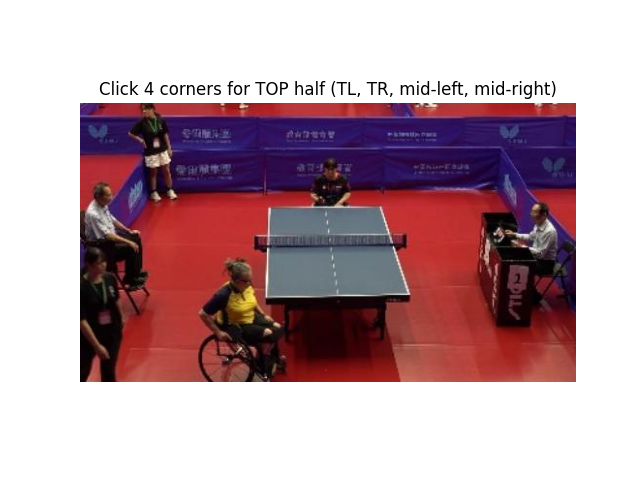

In [ ]:
frame_indices = [
    dataset.num_frames // 2 - random.randint(0, 100),
    # dataset.num_frames // 2 - random.randint(0, 100),
    # dataset.num_frames // 2 + random.randint(0, 100),
    dataset.num_frames // 2 + random.randint(0, 100),
]

converted_img_paths = []

for i, idx in enumerate(frame_indices):
    filename = f"{idx:06d}.jpg"
    img_path = os.path.join(frame_dir, filename)

    img = Image.open(img_path).convert("RGB")
    # img_trans = transforms.CenterCrop(size=(224,224))
    img_trans = transforms.Resize((288, 512))
    converted_img = img_trans(img)

    os.makedirs('./result', exist_ok=True)
    converted_img_path = os.path.join('./result', f'converted_{i}.jpg')
    converted_img.save(converted_img_path)
    converted_img_paths.append(converted_img_path)

table_detector = TableDetector(image_path=converted_img_paths[0], topdown_width=1525, topdown_height=2740)

table_detector.detect_corners_and_compute()